# Import libraries

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load Data 

In [4]:
df = pd.read_csv("cleaned_dataset/saas_cleaned_data.csv")
df.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,account_seats,is_trial,churn_flag,...,usage_duration_secs,error_count,total_tickets,resolution_time_hours,first_response_time_minutes,satisfaction_score,escalation_flag,churned,tenure_days,seat_utilization
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,152339,38,2.0,23.000000,91.000000,3.000000,0.0,1.0,550,3.466667
1,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,152339,38,2.0,23.000000,91.000000,3.000000,0.0,1.0,550,3.466667
2,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,...,101136,14,3.0,38.000000,73.333333,4.000000,0.0,0.0,976,1.222222
3,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,...,251210,48,3.0,43.666667,63.666667,4.666667,0.0,1.0,600,18.800000
4,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,...,251210,48,3.0,43.666667,63.666667,4.666667,0.0,1.0,600,18.800000


# 1. BASIC OVERVIEW & DATA AUDIT

In [5]:
# Shape
print("Shape:", df.shape)

# Columns
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Duplicate check
print("\nDuplicates:", df.duplicated().sum())

Shape: (748, 25)

Columns:
 Index(['account_id', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier', 'account_seats', 'is_trial',
       'churn_flag', 'mrr_amount', 'arr_amount', 'subscription_seats',
       'total_subscriptions', 'usage_count', 'usage_duration_secs',
       'error_count', 'total_tickets', 'resolution_time_hours',
       'first_response_time_minutes', 'satisfaction_score', 'escalation_flag',
       'churned', 'tenure_days', 'seat_utilization'],
      dtype='object')

Data Types:
 account_id                      object
account_name                    object
industry                        object
country                         object
signup_date                     object
referral_source                 object
plan_tier                       object
account_seats                    int64
is_trial                          bool
churn_flag                        bool
mrr_amount                     float64
arr_amount                  

# 2. DESCRIPTIVE STATISTICS

In [6]:
# Overall stats
print(df.describe())

# Churn vs Non-Churn comparison
churn_summary = df.groupby('churned')[[
    'mrr_amount', 'usage_count', 'total_tickets',
    'tenure_days', 'seat_utilization', 'satisfaction_score'
]].mean()

print("\nChurn Summary:\n", churn_summary)

       account_seats    mrr_amount     arr_amount  subscription_seats  \
count     748.000000    748.000000     748.000000          748.000000   
mean       20.225936   2234.116224   26809.394690           29.662866   
std        20.436692   1556.463230   18677.558762           16.812541   
min         1.000000     95.000000    1140.000000            4.500000   
25%         5.000000   1219.066667   14628.800000           19.750000   
50%        14.000000   1892.279762   22707.357143           25.500000   
75%        28.000000   2812.791667   33753.500000           33.375000   
max       163.000000  13806.000000  165672.000000          163.000000   

       total_subscriptions  usage_count  usage_duration_secs  error_count  \
count           748.000000   748.000000           748.000000   748.000000   
mean              9.931818   498.145722        151256.911765    28.260695   
std               3.247803   171.857998         51886.425375    12.070307   
min               2.000000    92.0

# 3. UNIVARIATE ANALYSIS

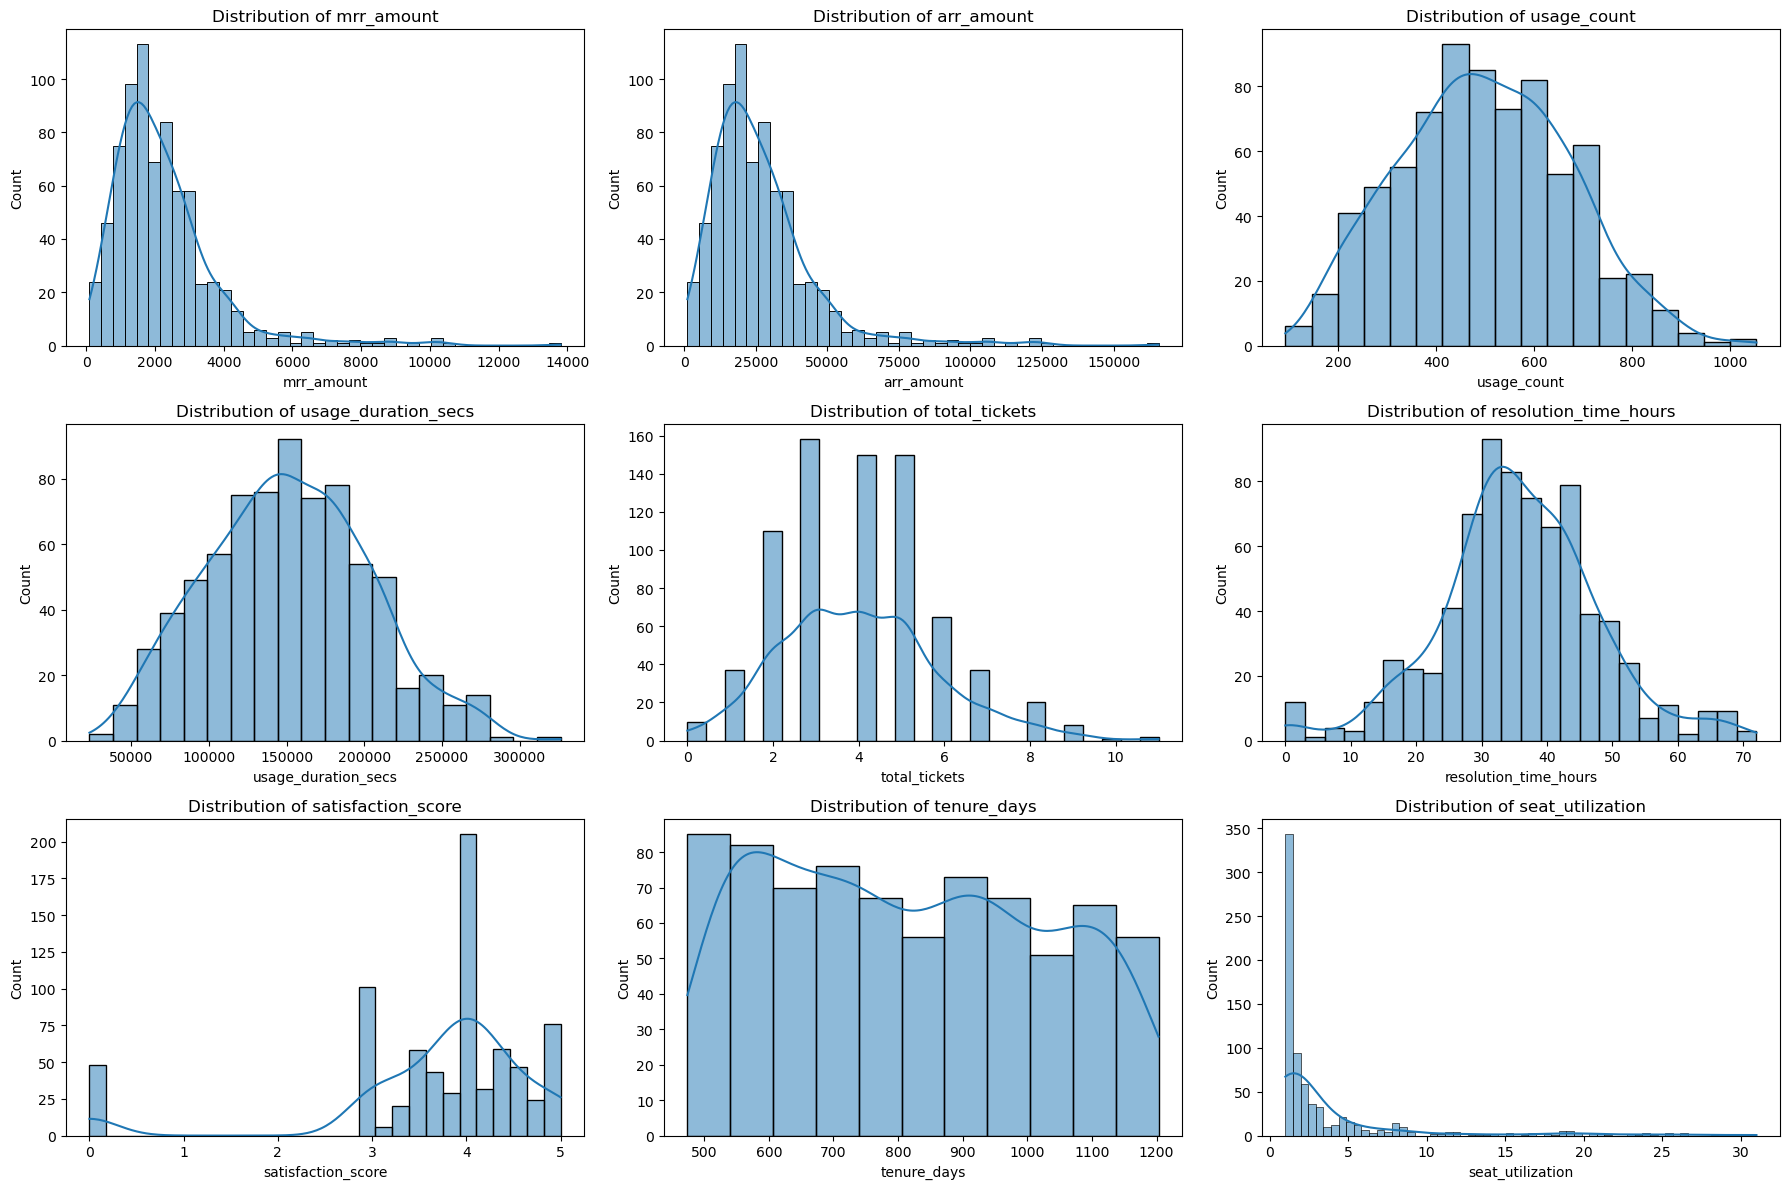

In [8]:
num_cols = [
    'mrr_amount', 'arr_amount', 'usage_count',
    'usage_duration_secs', 'total_tickets',
    'resolution_time_hours', 'satisfaction_score',
    'tenure_days', 'seat_utilization'
]

# Set up the grid: adjust rows/cols depending on how many plots you want per row
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# 4. CATEGORICAL ANALYSIS

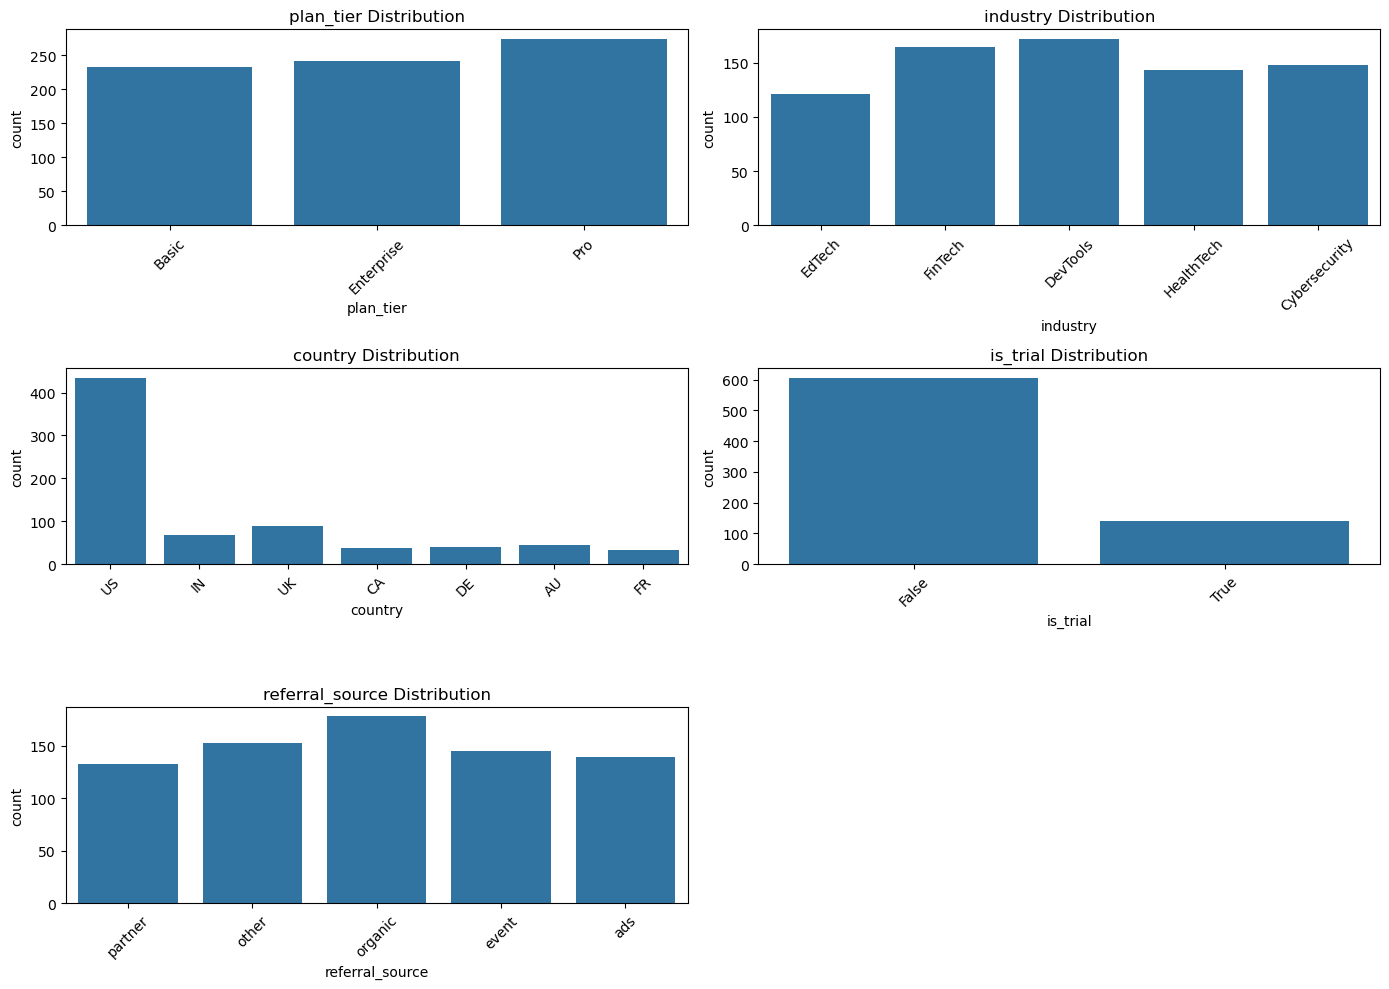

In [10]:
cat_cols = ['plan_tier', 'industry', 'country', 'is_trial', 'referral_source']

# Grid setup: adjust n_cols to control how many plots per row
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots if grid > number of columns
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 5. BIVARIATE ANALYSIS

## A. Numerical vs Churn

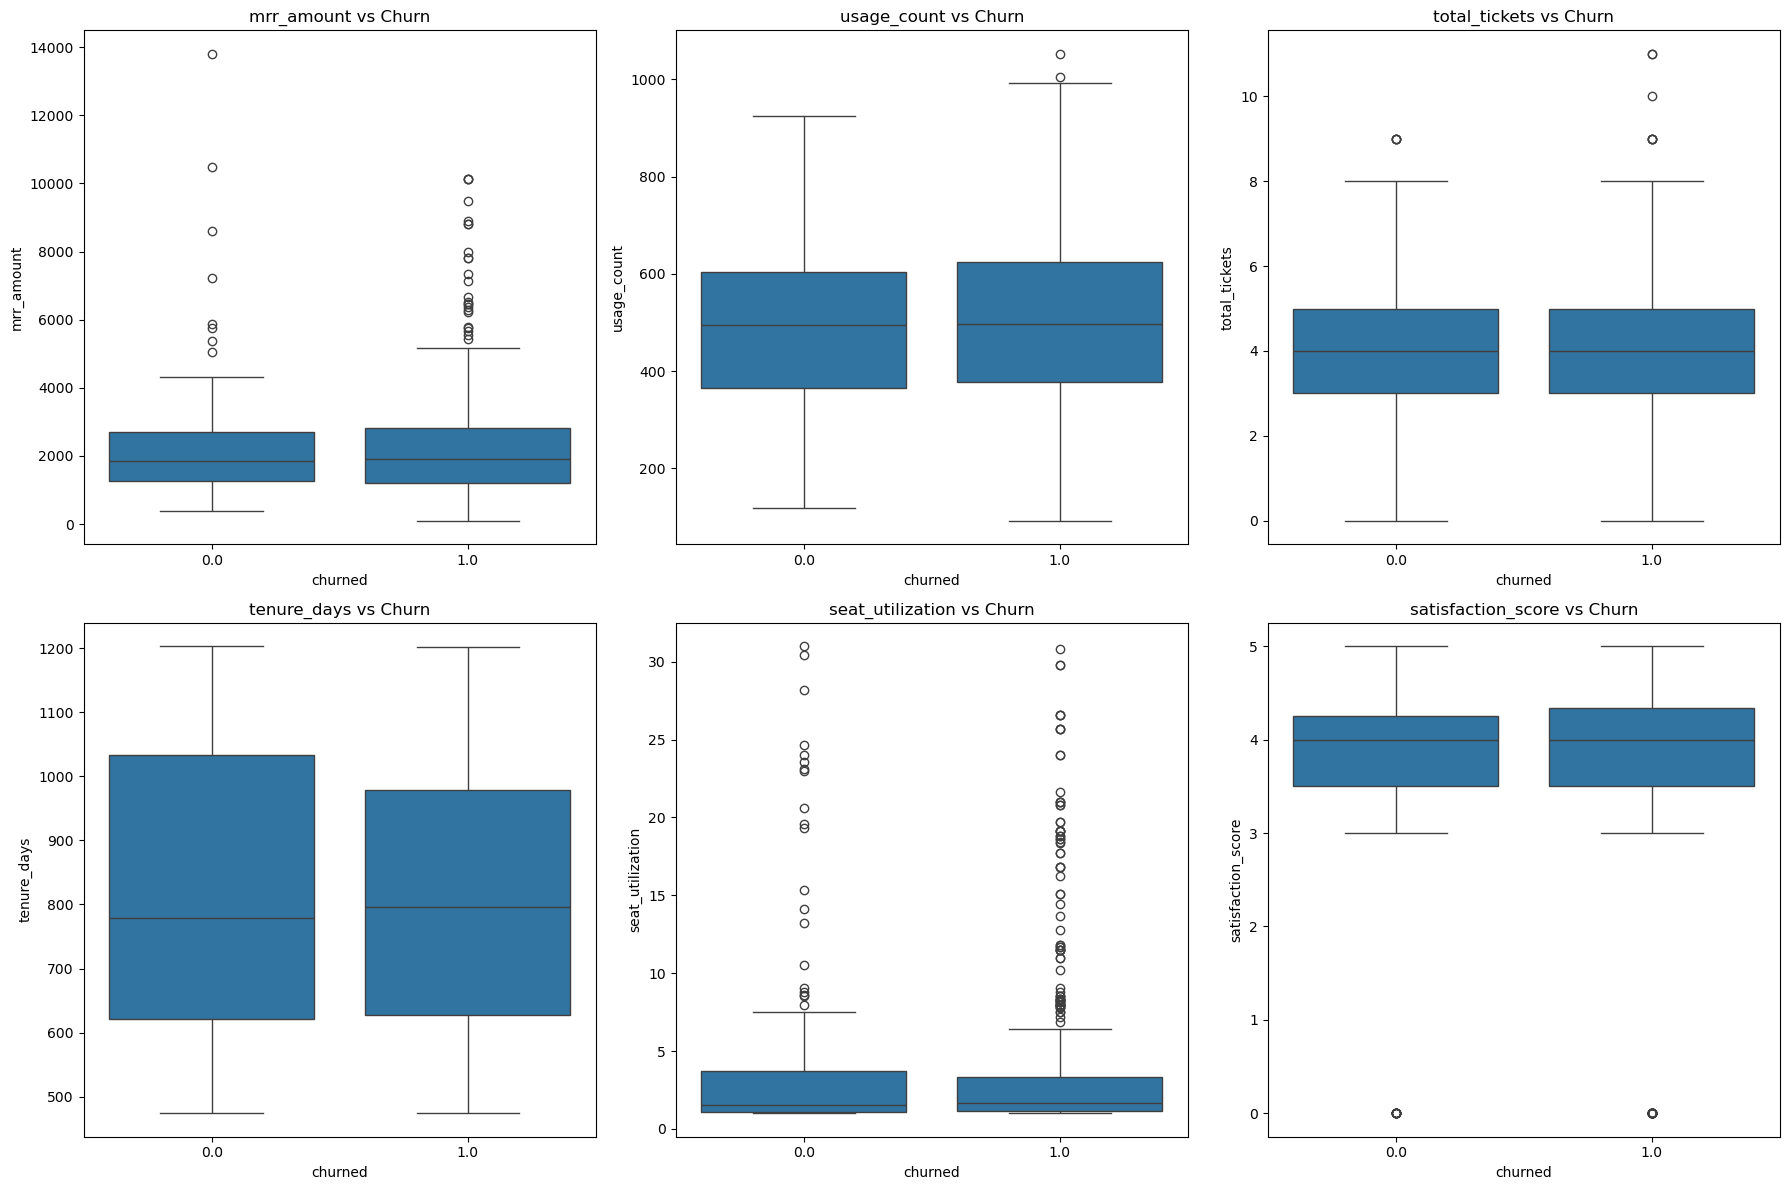

In [11]:
features = [
    'mrr_amount', 'usage_count', 'total_tickets',
    'tenure_days', 'seat_utilization', 'satisfaction_score'
]

# Grid setup: adjust n_cols to control how many plots per row
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='churned', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")

# Remove unused subplots if grid > number of features
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## B. Categorical vs Churn

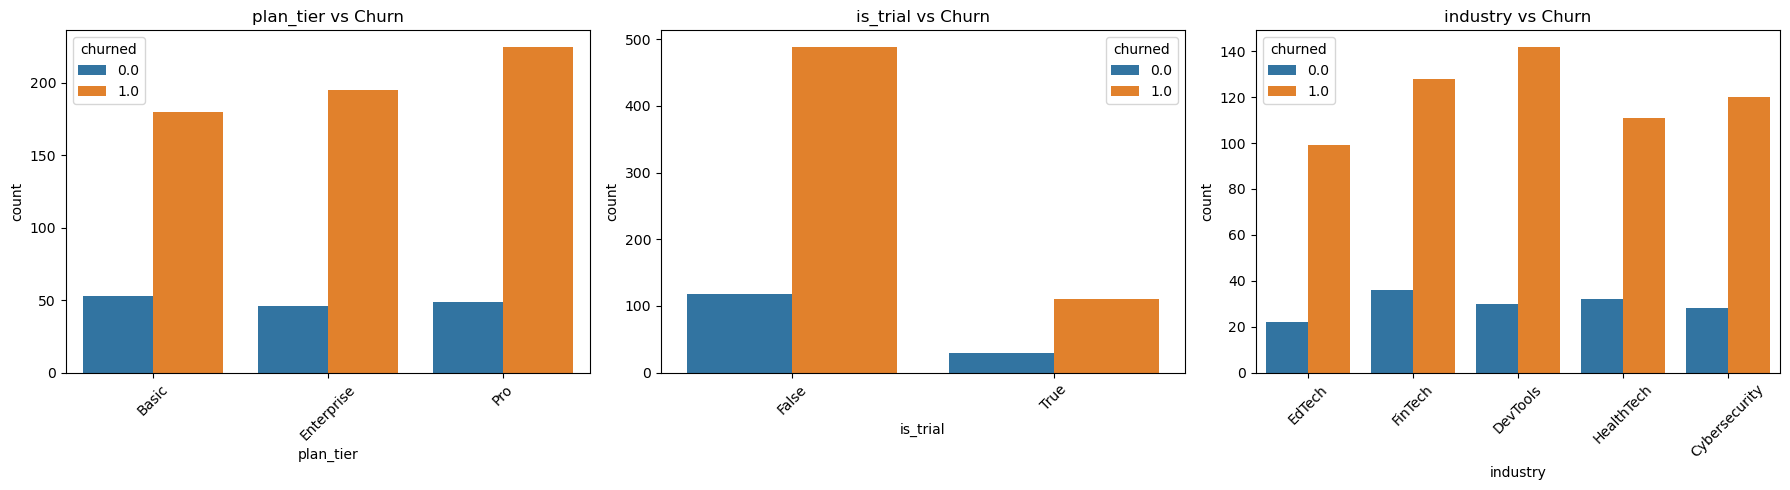

In [13]:
cat_cols = ['plan_tier', 'is_trial', 'industry']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))

for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, hue='churned', data=df, ax=ax)
    ax.set_title(f"{col} vs Churn")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## C. Correlation Heatmap

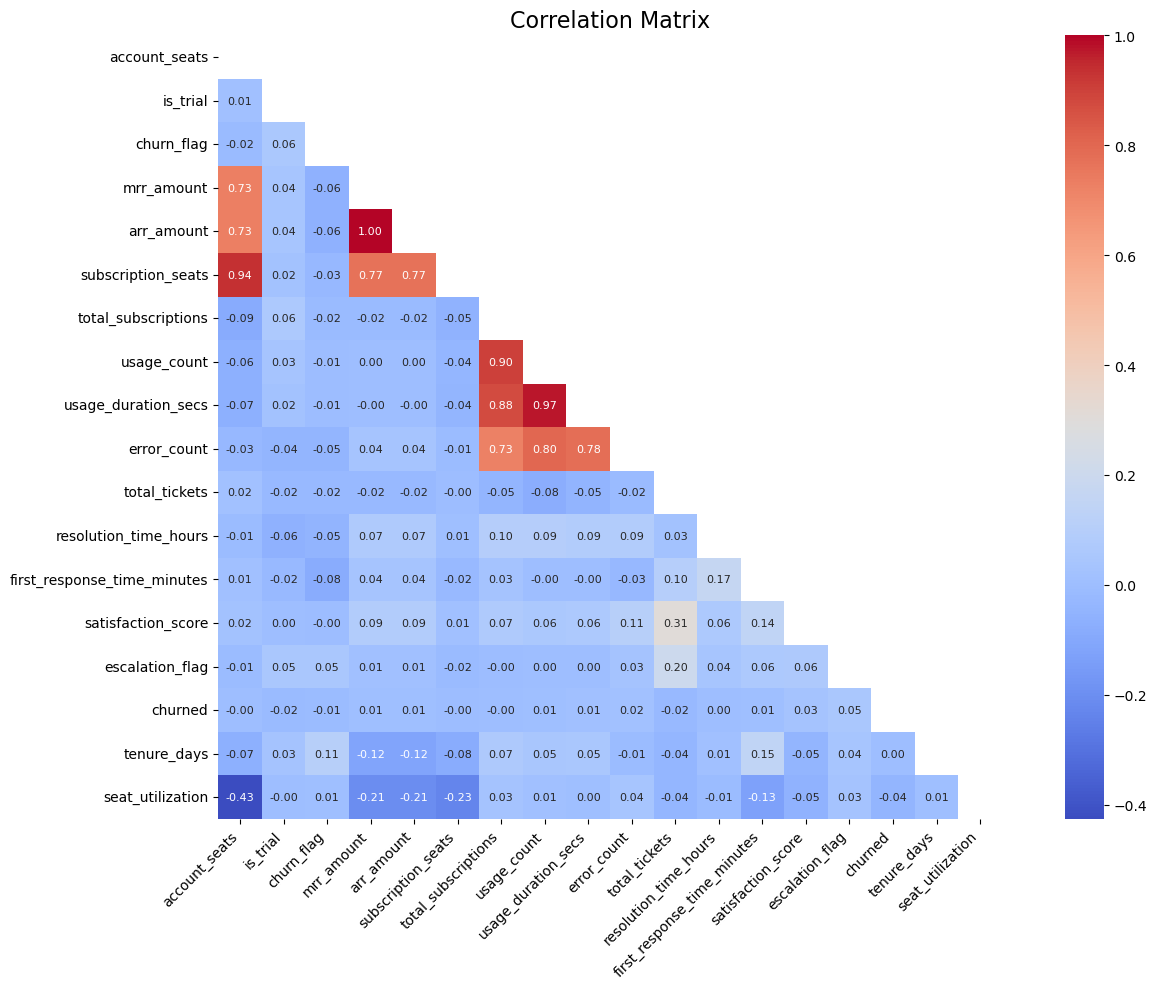

In [16]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar=True, 
    square=True,
    annot_kws={"size":8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# 6. MULTIVARIATE ANALYSIS

## A. Usage vs Tickets vs Churn

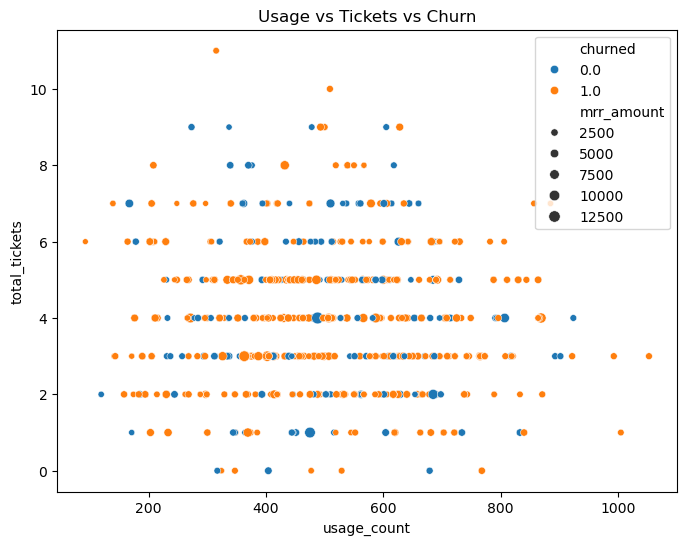

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='usage_count',
    y='total_tickets',
    hue='churned',
    size='mrr_amount',
    data=df
)
plt.title("Usage vs Tickets vs Churn")
plt.show()

## B. Tenure vs Revenue vs Churn

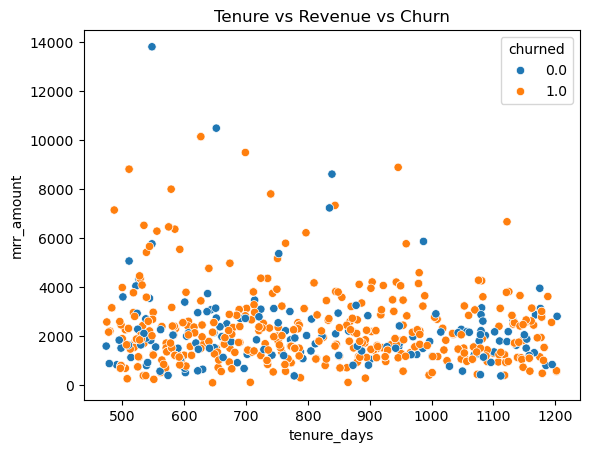

In [18]:
sns.scatterplot(
    x='tenure_days',
    y='mrr_amount',
    hue='churned',
    data=df
)
plt.title("Tenure vs Revenue vs Churn")
plt.show()

## C. Seat Utilization Impact

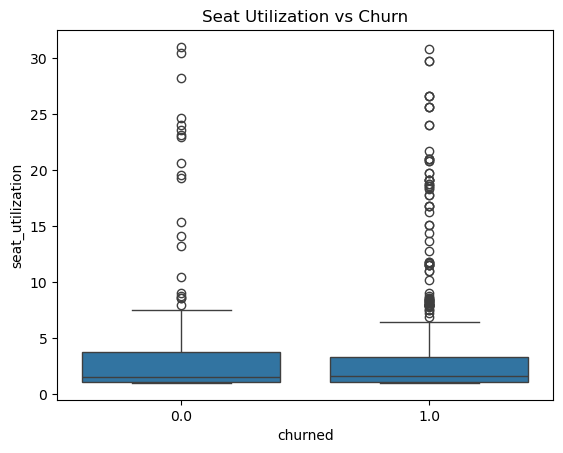

In [19]:
sns.boxplot(x='churned', y='seat_utilization', data=df)
plt.title("Seat Utilization vs Churn")
plt.show()

# 7. A/B TESTING (STATISTICAL ANALYSIS)

## A. Example: Trial vs Non-Trial (Churn Impact)

In [21]:
trial = df[df['is_trial'] == 1]['churned']
non_trial = df[df['is_trial'] == 0]['churned']

t_stat, p_value = ttest_ind(trial, non_trial)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.49258613982119137
P-Value: 0.6224499841965516


### Interpretation:
- p < 0.05 → Significant difference
- p > 0.05 → No strong evidence

### Insight:

- “Trial users churn significantly more than non-trial users”

## B. Plan Tier A/B Test

In [22]:
basic = df[df['plan_tier'] == 'Basic']['churned']
pro = df[df['plan_tier'] == 'Pro']['churned']

t_stat, p_value = ttest_ind(basic, pro)

print("P-Value (Basic vs Pro):", p_value)

P-Value (Basic vs Pro): 0.17405777401113076


## C. High vs Low Usage (Create Groups)

In [24]:
df['usage_group'] = pd.qcut(df['usage_count'], q=2, labels=['Low', 'High'])

low_usage = df[df['usage_group'] == 'Low']['churned']
high_usage = df[df['usage_group'] == 'High']['churned']

t_stat, p_value = ttest_ind(low_usage, high_usage)

print("P-Value (Usage Impact):", p_value)

P-Value (Usage Impact): 1.0


# 8. CHURN RATE ANALYSIS

In [31]:
# By Plan
churn_rate_plan = df.groupby('plan_tier')['churned'].mean()
print(churn_rate_plan)

print(10*"---")

# By Trial
churn_rate_trial = df.groupby('is_trial')['churned'].mean()
print(churn_rate_trial)

plan_tier
Basic         0.772532
Enterprise    0.809129
Pro           0.821168
Name: churned, dtype: float64
------------------------------
is_trial
False    0.805601
True     0.787234
Name: churned, dtype: float64


# FINAL INSIGHTS